In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
plt.rcParams['figure.figsize']=(8,5)

In [ ]:
df=pd.read_csv('marketing_campaign.csv',sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Income']=SimpleImputer(strategy='median').fit_transform(df[['Income']])
df=df.drop_duplicates()

In [ ]:
df['Age']=2026-df['Year_Birth']
df['TotalSpend']=df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df['Children']=df['Kidhome']+df['Teenhome']

In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpend,Children
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,57.194196,605.798214,0.950446
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,602.249288,0.751803
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,30.000000,5.000000,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,49.000000,68.750000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,56.000000,396.000000,1.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,67.000000,1045.500000,1.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,133.000000,2525.000000,3.000000


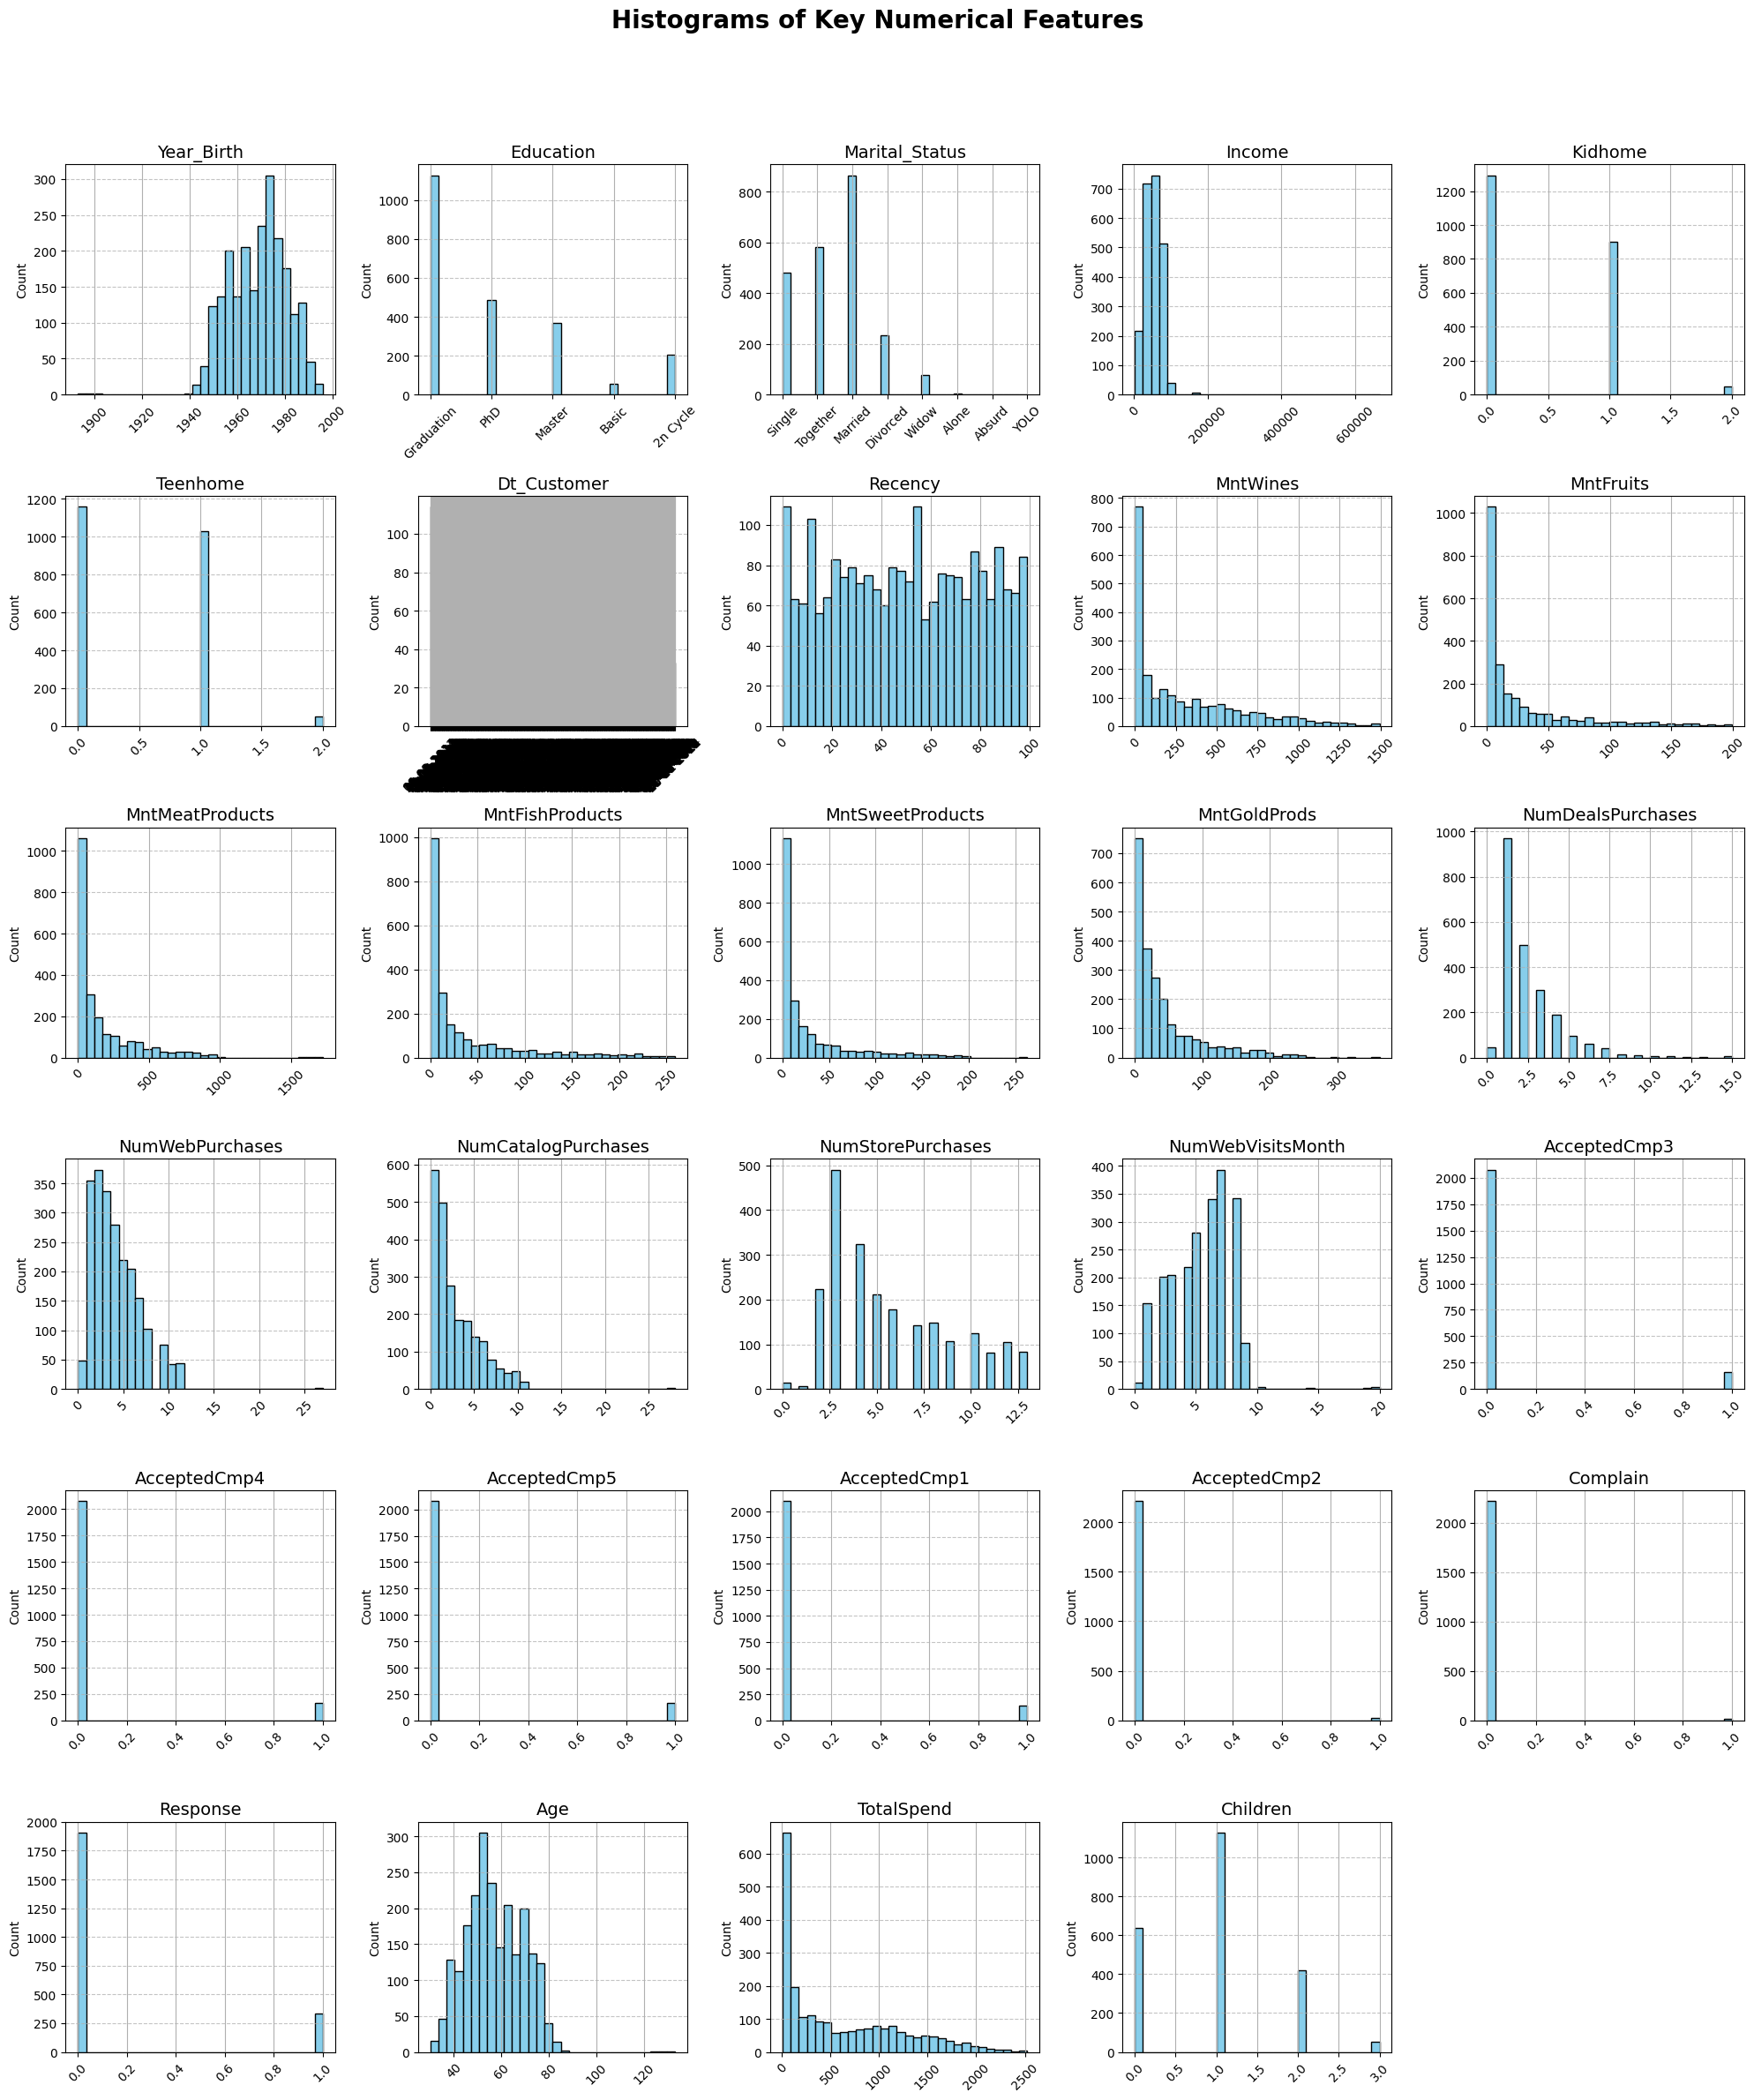

In [ ]:
import matplotlib.pyplot as plt


columns_to_exclude = ['ID', 'Z_CostContact', 'Z_Revenue']
df_for_hist = df.drop(columns=columns_to_exclude, errors='ignore')


num_cols_to_plot = len(df_for_hist.columns)
num_rows = (num_cols_to_plot // 5) + (1 if num_cols_to_plot % 5 > 0 else 0)


fig, axes = plt.subplots(num_rows, 5, figsize=(20, 4 * num_rows))


axes_flat = axes.flatten()


for i, col in enumerate(df_for_hist.columns):
    ax = axes_flat[i]
    df_for_hist[col].hist(ax=ax, bins=30, color='skyblue', edgecolor='black')
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.set_title(col, fontsize=14)
    ax.set_xlabel('', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', alpha=0.75, linestyle='--')


for j in range(num_cols_to_plot, len(axes_flat)):
    fig.delaxes(axes_flat[j])


plt.suptitle('Histograms of Key Numerical Features', y=1.02, fontsize=20, weight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

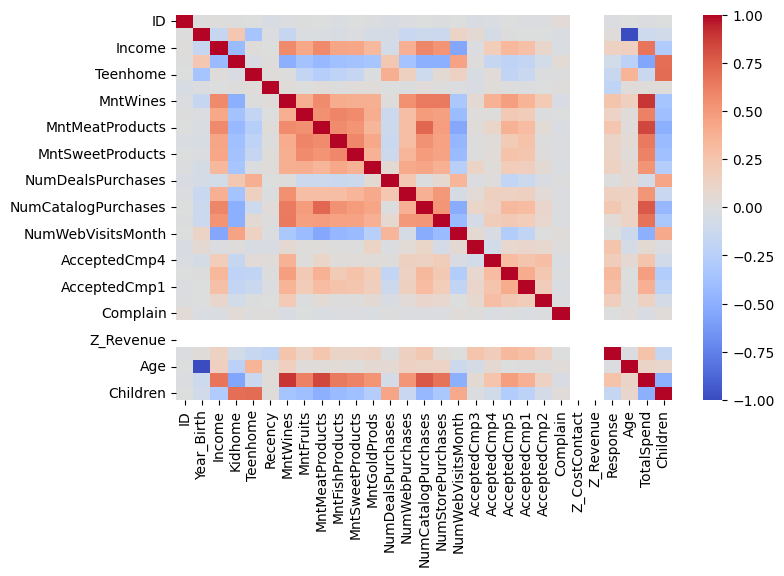

In [ ]:
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.show()

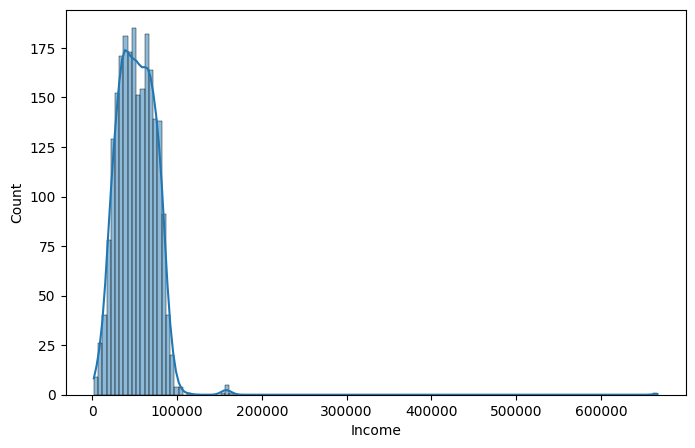

In [ ]:
sns.histplot(df['Income'],kde=True)
plt.show()

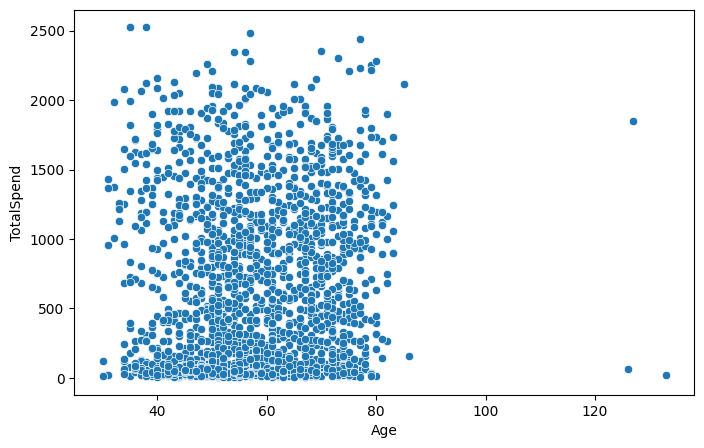

In [ ]:
sns.scatterplot(data=df,x='Age',y='TotalSpend')
plt.show()

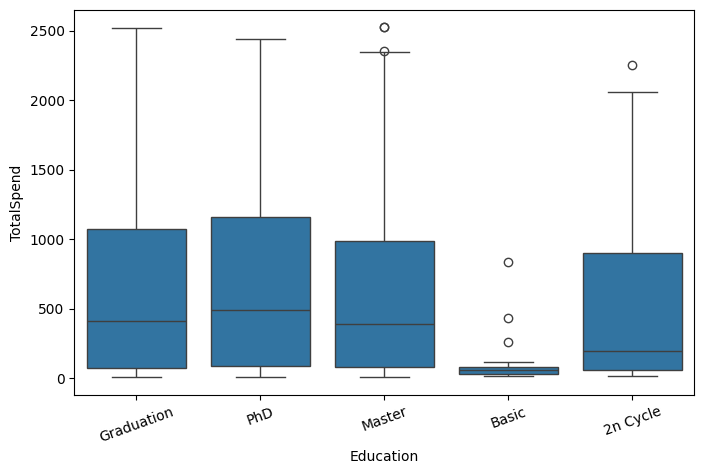

In [ ]:
sns.boxplot(data=df,x='Education',y='TotalSpend')
plt.xticks(rotation=20);plt.show()

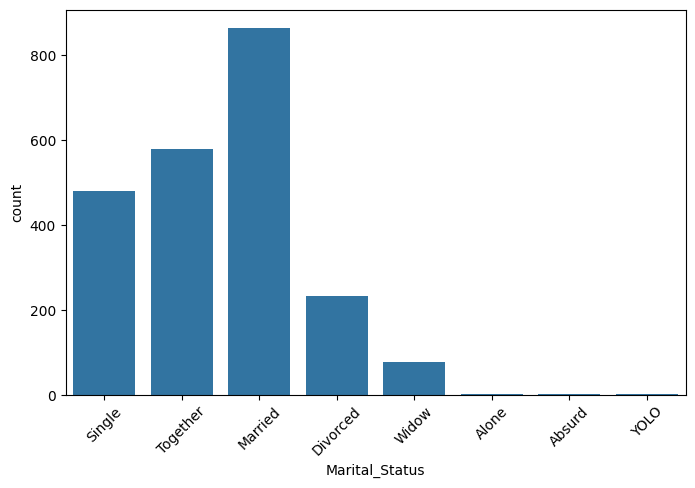

In [ ]:
sns.countplot(data=df,x='Marital_Status')
plt.xticks(rotation=45)
plt.show()

In [ ]:
features=['Income','Age','TotalSpend','Children','NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth']
X=df[features]

In [ ]:
X_scaled=StandardScaler().fit_transform(X)

In [ ]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)

[0.48639829 0.14439443]


Explained Variance Ratio: [0.48639829 0.14439443]
Total Variance Retained: 0.6307927183996058


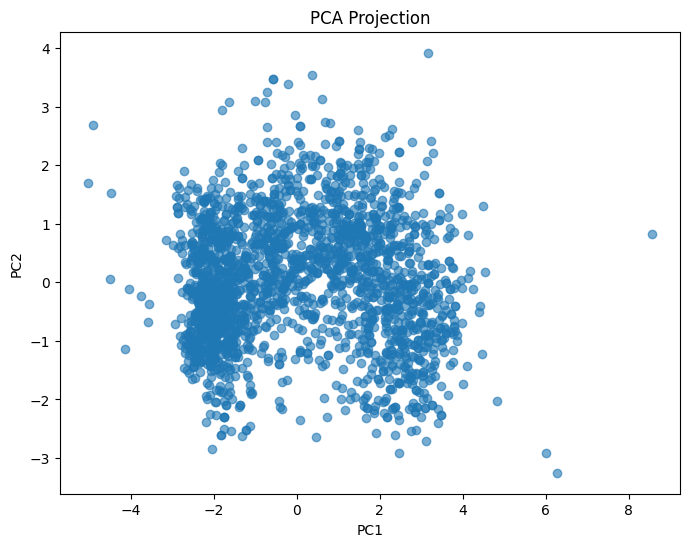

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

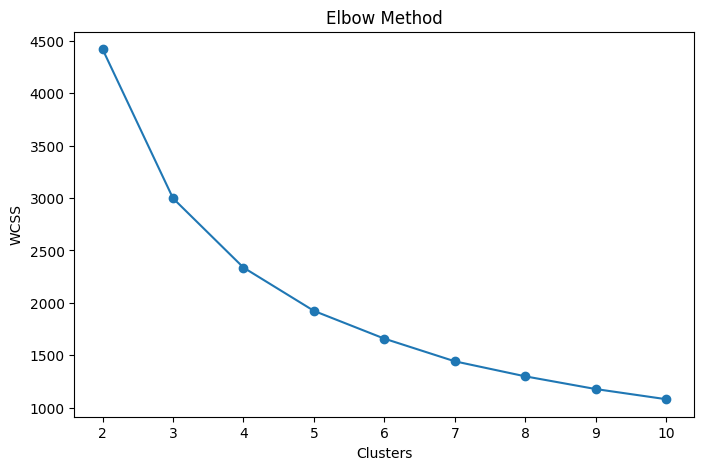

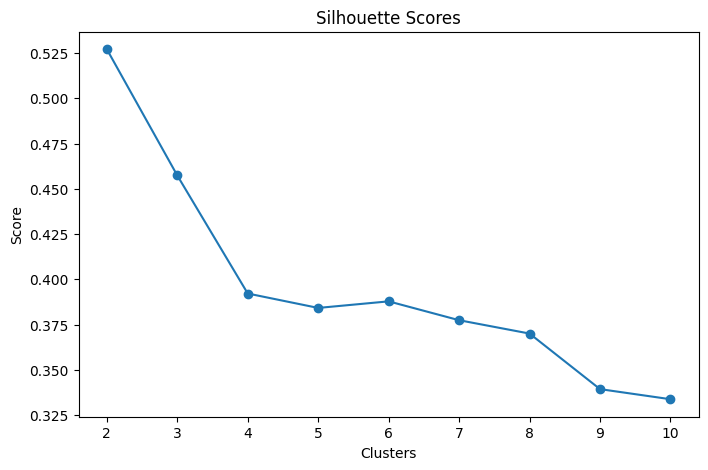

Suggested K: 2


In [ ]:
wcss=[]
sil=[]

for k in range(2,11):
    model=KMeans(n_clusters=k, random_state=42, n_init=10)
    labels=model.fit_predict(X_pca)
    wcss.append(model.inertia_)
    sil.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(8,5))
plt.plot(range(2,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(2,11),sil,marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Clusters")
plt.ylabel("Score")
plt.show()

best_k = range(2,11)[np.argmax(sil)]
print("Suggested K:", best_k)

In [ ]:
best_k=4
km=KMeans(n_clusters=best_k,random_state=42,n_init=10)
df['Cluster']=km.fit_predict(X_scaled)

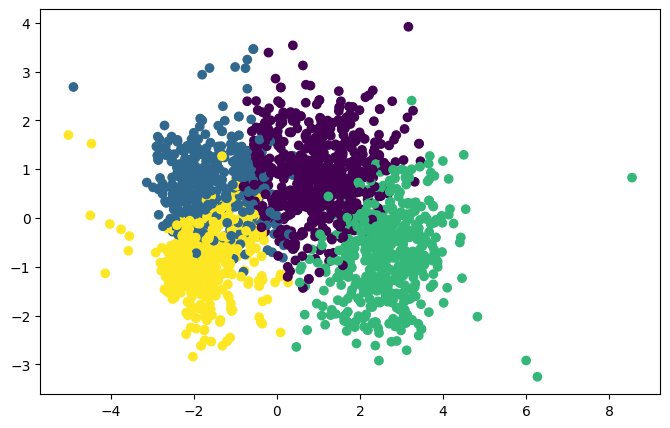

In [ ]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=df['Cluster'])
plt.show()

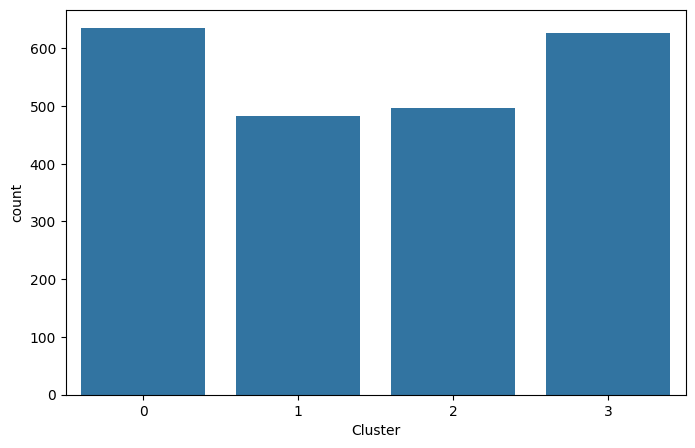

In [ ]:
sns.countplot(x='Cluster',data=df)
plt.show()

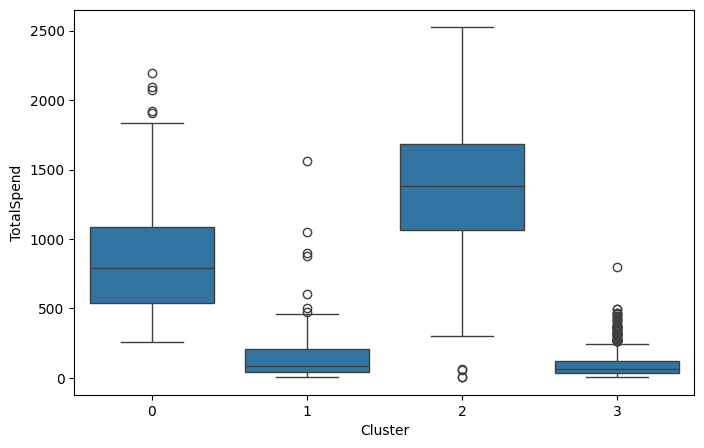

In [ ]:
sns.boxplot(data=df,x='Cluster',y='TotalSpend')
plt.show()

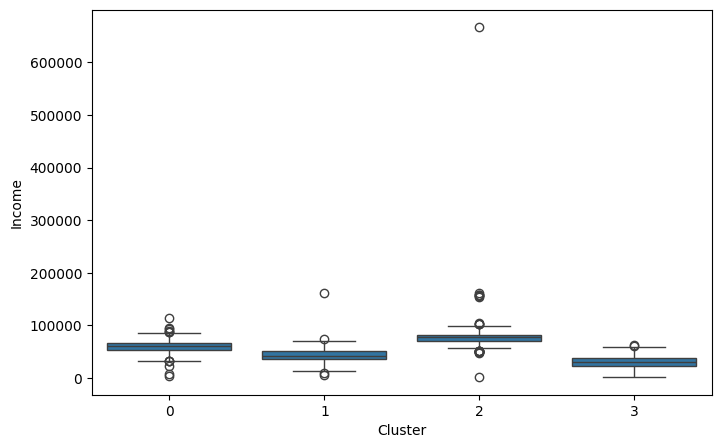

In [ ]:
sns.boxplot(data=df,x='Cluster',y='Income')
plt.show()

,Income,Age,TotalSpend,Children,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,,,
0,60559.344882,60.640945,848.724409,1.023622,6.935433,3.348031,8.094488,5.645669
1,42667.815735,62.741201,138.151139,1.879917,2.395445,0.795031,3.631470,5.975155
2,78776.768145,57.657258,1388.282258,0.118952,4.487903,6.300403,8.288306,2.318548
3,30153.432907,49.051118,100.212460,0.817891,2.177316,0.523962,3.138978,6.849840


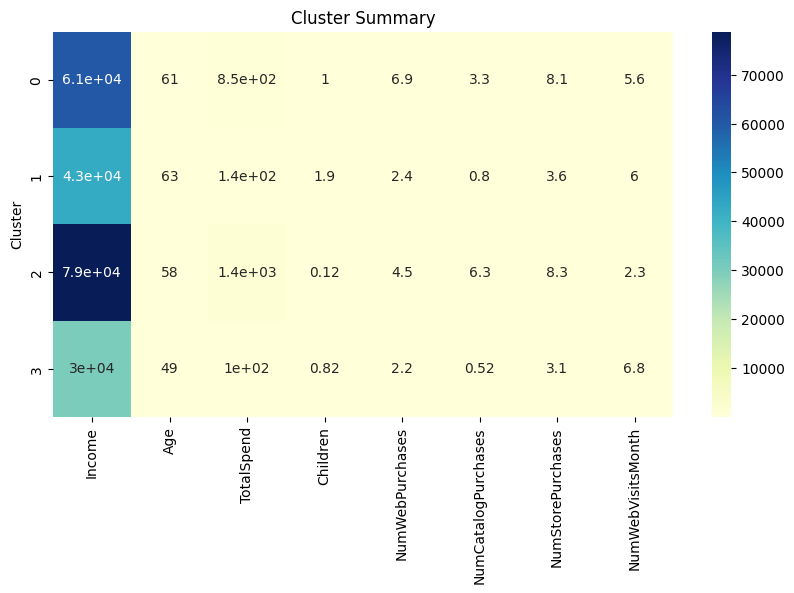

In [ ]:
cluster_summary = df.groupby('Cluster')[['Income','Age','TotalSpend','Children','NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth']].mean()
display(cluster_summary)

plt.figure(figsize=(10,5))
sns.heatmap(cluster_summary, annot=True, cmap='YlGnBu')
plt.title("Cluster Summary")
plt.show()

In [ ]:
personas={0:'Budget Buyers',1:'Premium Customers',2:'Digital Shoppers',3:'Family Focused'}
df['Persona']=df['Cluster'].map(personas)
df[['Cluster','Persona']].drop_duplicates()

,Cluster,Persona
0,2,Digital Shoppers
1,1,Premium Customers
2,0,Budget Buyers
3,3,Family Focused


In [ ]:
for p in df['Persona'].unique():
 print(f'- {p}: targeted campaigns and personalized offers.')

- Digital Shoppers: targeted campaigns and personalized offers.
- Premium Customers: targeted campaigns and personalized offers.
- Budget Buyers: targeted campaigns and personalized offers.
- Family Focused: targeted campaigns and personalized offers.


In [ ]:
print('PCA reduced dimensionality, Elbow & Silhouette selected K, K-Means created actionable customer segments.')

PCA reduced dimensionality, Elbow & Silhouette selected K, K-Means created actionable customer segments.
